In [1]:
from data_saver import DataStorage
import pandas as pd
import numpy as np
import json
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from baseline import W2VSentenceEmbedder, SupportModel
from data_saver import DataStorage
import joblib
from sklearn.decomposition import PCA

In [5]:
w2v = W2VSentenceEmbedder()
sm = SupportModel(emb_model = w2v)


In [28]:
data = pd.read_csv('data\goemotions_balanced.csv')
X = data['text']
y = data['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.4, random_state = 42, shuffle = True, stratify = y)
# X_train = sm.emb(list(X_train))
# X_test = sm.emb(list(X_test))
print(len(X))
X = sm.emb(list(X))

73960


In [29]:
X = np.array(X)

mask = (X == 0).all(axis=1)
X = X[mask != 1]
y = y[mask != 1]
# X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.4, random_state = 42, shuffle = True, stratify = y)
len(X), X_train.shape, len(sm.emb.stats)

(32743, (29584,), 73960)

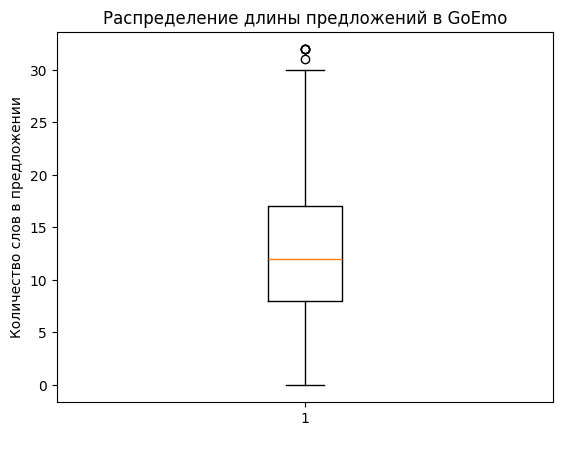

In [30]:
import matplotlib.pyplot as plt
plt.boxplot(sm.emb.stats)
plt.title("Распределение длины предложений в GoEmo")
plt.ylabel('Количество слов в предложении')
plt.xlabel(" ")
plt.show()

In [ ]:
# for path in Path(r"data\annotation_edited").rglob('*.json'):
#     with open(path, 'r', encoding='utf-8') as f:
#         data = json.load(f)
#         X.append(data['emoted_caption'])
#         y.append(data['emotion'])
y = np.array(y)
for emo in set(y):
    print(f'Emotion: {emo}, prob: {len(y[y == 'anger']) / len(y)}')


SyntaxError: f-string: unmatched '[' (3978425547.py, line 8)

In [35]:
df = pd.DataFrame(data[mask != 1])
df['stats'] = np.array(sm.emb.stats)[mask != 1]
df.to_csv('goemo_trunc_stats.csv', index=False, sep=';')
df

,text,label,stats
2,"Damn it, I only have 6 comments on this sub, I...",disgust,14
3,Sounds like a great way to accidentally fuckin...,anger,14
7,I'm going to steal this and pretend I came up ...,excitement,21
8,I wish I could get a lazy Malinois. I love the...,sadness,24
12,And my apologies if I misinterpreted but you s...,sadness,24
...,...,...,...
73952,"It's not like the picture looks bad. Wait, no,...",anger,22
73954,i wear all black. always. i died when we launc...,disgust,15
73955,I probably should have seen that... I watched ...,disgust,17
73956,😅 I wrote that to indicate tears of relief and...,amusement,23


In [ ]:
import optuna
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score
def objective(trial):
    c = trial.suggest_float('c', 0.0, 100)
    l1_rat = trial.suggest_float('l1_r', 0., 1.)
    model = LogisticRegression(penalty='elasticnet', C = c, l1_ratio=l1_rat, solver='saga')
    model = model.fit(X_train, y_train)

    pred = model.predict(X_test)
    return f1_score(y_test, pred, average='macro'), accuracy_score(y_test, pred)

study = optuna.create_study(directions=["maximize", "maximize"])


study.optimize(objective, n_trials=100)

In [17]:
X_val = []
y_val = []
for path in Path(r"data\annotation_edited").rglob('*.json'):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        X_val.append(data['emoted_caption'])
        y_val.append(data['emotion'])

X_val = sm.emb(X_val)

In [18]:
from sklearn.metrics import classification_report
model = LogisticRegression(penalty='elasticnet', C = 70.56604293809767, l1_ratio=0.2377096570075311, solver='saga', max_iter=500)
model.fit(X_train, y_train)
pred_val = model.predict(X_val)
print(classification_report(y_val, pred_val))

              precision    recall  f1-score   support

   amusement       0.42      0.07      0.12      1154
       anger       0.41      0.03      0.05      2913
         awe       0.23      0.13      0.17      1097
 contentment       0.18      0.18      0.18      1354
     disgust       0.18      0.24      0.21      1299
  excitement       0.20      0.10      0.13      1498
        fear       0.23      0.79      0.36      2407
     sadness       0.45      0.08      0.14      1559

    accuracy                           0.23     13281
   macro avg       0.29      0.20      0.17     13281
weighted avg       0.30      0.23      0.17     13281



In [ ]:
def objective(trial):
    c = trial.suggest_float('c', 0.0, 100)
    ker = trial.suggest_categorical('ker', ['linear', 'poly', 'rbf', 'sigmoid'])
    deg = trial.suggest_int('deg', 1, 7)
    g = trial.suggest_float('g', 0.1, 11.)
    model = SVC(kernel=ker, C = c, degree = deg, gamma = g)
    model = model.fit(X_train, y_train)

    pred = model.predict(X_test)
    return f1_score(y_test, pred, average='macro'), accuracy_score(y_test, pred)

study = optuna.create_study(directions=["maximize", "maximize"])


study.optimize(objective, n_trials=100)

[I 2026-06-25 21:55:55,295] A new study created in memory with name: no-name-095a0e12-9c34-41dc-8b82-801bba6bcbf1


In [19]:
svc = SVC()
svc = svc.fit(X_train, y_train)
pred = svc.predict(X_val)
print(classification_report(y_val, pred))

              precision    recall  f1-score   support

   amusement       0.62      0.05      0.10      1154
       anger       0.29      0.00      0.00      2913
         awe       0.20      0.38      0.27      1097
 contentment       0.29      0.05      0.09      1354
     disgust       0.15      0.14      0.15      1299
  excitement       0.35      0.02      0.04      1498
        fear       0.23      0.91      0.37      2407
     sadness       0.87      0.01      0.02      1559

    accuracy                           0.22     13281
   macro avg       0.37      0.20      0.13     13281
weighted avg       0.36      0.22      0.13     13281



---------------------------------------------------------------------------------